Regiones y fronteras

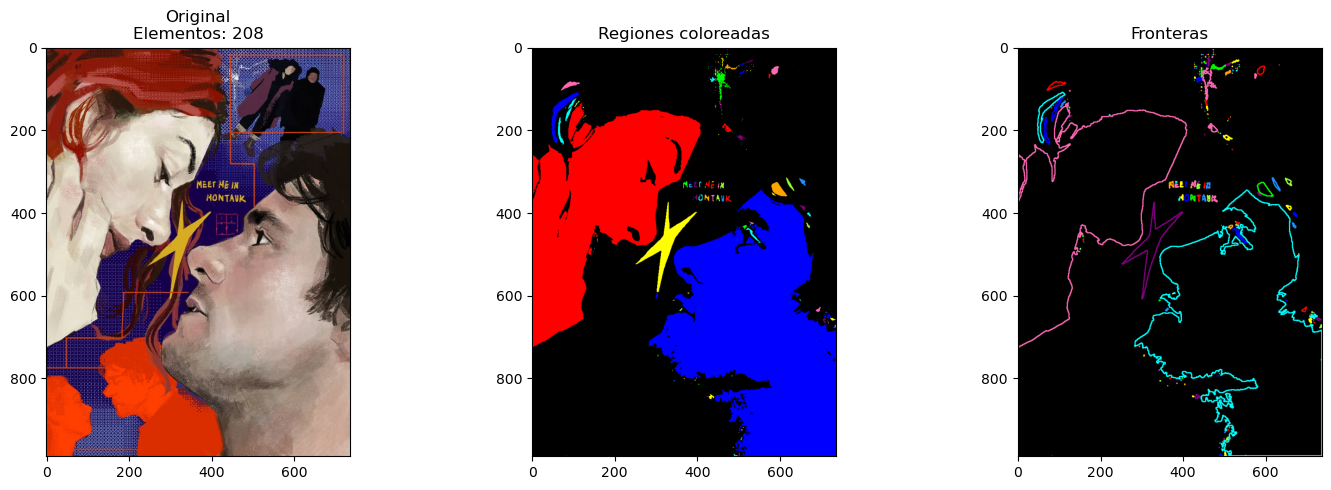

Total regiones: 208

-- REGIONES --
color 255, 0, 0 (Rojo) objetos 21
color 0, 255, 0 (Verde) objetos 21
color 0, 0, 255 (Azul) objetos 21
color 255, 255, 0 (Amarillo) objetos 21
color 128, 0, 128 (Morado) objetos 21
color 0, 255, 255 (Cyan) objetos 21
color 255, 165, 0 (Naranja) objetos 21
color 255, 105, 180 (Rosa) objetos 21
color 150, 255, 50 (Lima) objetos 20
color 30, 144, 255 (Celeste) objetos 20

-- FRONTERAS --
color 255, 0, 0 (Rojo) objetos 21
color 0, 255, 0 (Verde) objetos 21
color 0, 0, 255 (Azul) objetos 21
color 255, 255, 0 (Amarillo) objetos 21
color 128, 0, 128 (Morado) objetos 21
color 0, 255, 255 (Cyan) objetos 21
color 255, 165, 0 (Naranja) objetos 21
color 255, 105, 180 (Rosa) objetos 21
color 150, 255, 50 (Lima) objetos 20
color 30, 144, 255 (Celeste) objetos 20


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
img = cv2.imread("hola.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
e_img = measure.label(binary, connectivity=2)
num_obj = np.max(e_img)
COLORES_FIJOS = {
    "Rojo":     [255,   0,   0],
    "Verde":    [  0, 255,   0],
    "Azul":     [  0,   0, 255],
    "Amarillo": [255, 255,   0],
    "Morado":   [128,   0, 128],
    "Cyan":     [  0, 255, 255],
    "Naranja":  [255, 165,   0],
    "Rosa":     [255, 105, 180],
    "Lima":     [150, 255,  50],
    "Celeste":  [ 30, 144, 255],
}
nombres = list(COLORES_FIJOS.keys())
valores = list(COLORES_FIJOS.values())
num_l, label = cv2.connectedComponents(binary)
color = np.array([[0, 0, 0]] + [
    valores[i % len(valores)] for i in range(num_l - 1)
], dtype=np.uint8)
colorear = color[label]
conteo_regiones = {}
for i in range(1, num_l):
    nombre = nombres[(i - 1) % len(nombres)]
    conteo_regiones[nombre] = conteo_regiones.get(nombre, 0) + 1
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = np.zeros((*gray.shape, 3), dtype=np.uint8)
conteo_fronteras = {}
for i, contorno in enumerate(contornos):
    nombre = nombres[i % len(nombres)]
    bgr = valores[i % len(valores)]
    cv2.drawContours(contorno_fin, contornos, i, bgr, 2)
    conteo_fronteras[nombre] = conteo_fronteras.get(nombre, 0) + 1
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Original\nElementos: {num_obj}")
plt.subplot(132)
plt.imshow(colorear)
plt.title("Regiones coloreadas")
plt.subplot(133)
plt.imshow(contorno_fin)
plt.title("Fronteras")
plt.tight_layout()
plt.show()
print(f"Total regiones: {num_l - 1}\n")
print("-- REGIONES --")
for nombre, cantidad in conteo_regiones.items():
    r, g, b = COLORES_FIJOS[nombre]
    print(f"color {r}, {g}, {b} ({nombre}) objetos {cantidad}")

print("\n-- FRONTERAS --")
for nombre, cantidad in conteo_fronteras.items():
    r, g, b = COLORES_FIJOS[nombre]
    print(f"color {r}, {g}, {b} ({nombre}) objetos {cantidad}")

Conteo

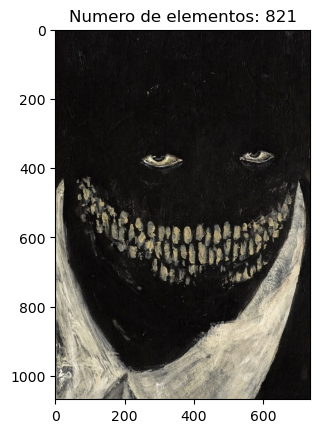

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img=measure.label(binary, connectivity=2)
    num_obj=np.max(e_img)
    return num_obj
img=cv2.imread("hola.jpg")
conteo=contar_elementos(img)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title(f"Numero de elementos: {conteo}")
plt.show()
